In [2]:
import numpy as np
import matplotlib.pyplot as plt

Case-1: No interaction between particles

In [84]:
class brownian_motion_without_interaction():
    def __init__(self,num_particles,time_steps):
        self.time_steps = time_steps
        self.num_particles = num_particles
        self.pos_x = np.zeros((time_steps,num_particles))
        self.pos_y = np.zeros((time_steps,num_particles))
        # self.pos_x = (np.random.rand(self.time_steps,self.num_particles)-0.5)*10
        # self.pos_y = (np.random.rand(self.time_steps,self.num_particles)-0.5)*10
    
    def simulate(self,delta):
        for i in range(self.time_steps-1):
            self.pos_x[i+1,:] = self.pos_x[i,:] + np.sqrt(2)*delta*np.random.normal(0,1,self.num_particles)
            self.pos_y[i+1,:] = self.pos_y[i,:] + np.sqrt(2)*delta*np.random.normal(0,1,self.num_particles)
        return self.pos_x,self.pos_y
    def plot(self):
        plt.figure(figsize=(10, 8))
        for i in range(self.num_particles):
            plt.plot(self.pos_x[:,i], self.pos_y[:,i], label=f"Particle {i+1}")
        plt.title("Brownian Motion without any interaction ")
        plt.xlabel("X Position")
        plt.ylabel("Y Position")
        plt.legend()

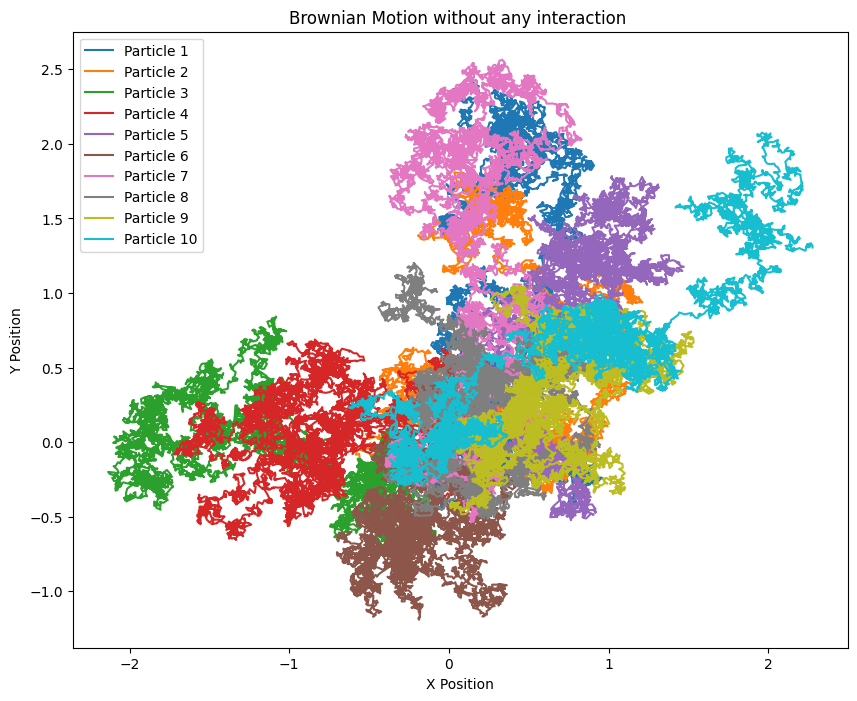

In [85]:
np.random.seed(20)
model = brownian_motion_without_interaction(10,10000)
model.simulate(0.01)
model.plot()

Case-2: With Leonard Jones Interactions

In [86]:
class brownian_motion_with_LJ_interaction():
    def __init__(self,num_particles,time_steps,epsilon,sigma=1.0):
        self.time_steps = time_steps
        self.num_particles = num_particles
        self.epsilon = epsilon
        self.sigma = sigma
        self.pos = np.zeros((num_particles,2))
        self.trajectories_x = np.zeros((time_steps,num_particles))
        self.trajectories_y = np.zeros((time_steps,num_particles))
        self.trajectories_x[0,:] = self.pos[:,0]
        self.trajectories_y[0,:] = self.pos[:,1]
    def lennard_jones_force(self):
        forces = np.zeros_like(self.pos)
        for i in range(self.num_particles):
            for j in range(self.num_particles):
                if i!=j:
                    displacement_ij = self.pos[j] - self.pos[i]
                    distance_ij = np.linalg.norm(displacement_ij)
                    if self.sigma < distance_ij < 2.5*self.sigma:
                        force_magnitude = 24*self.epsilon*( 2*(self.sigma/distance_ij)**13 - (self.sigma/distance_ij)**7)
                        forces[i] += force_magnitude * displacement_ij / distance_ij
        return forces
    def simulate(self,delta):
        for i in range(self.time_steps-1):
            lj_force = self.lennard_jones_force()
            thermal_motion = np.sqrt(2)*delta*np.random.normal(0,1,(self.num_particles,2))
            self.pos += thermal_motion + lj_force*(delta**2)

            self.trajectories_x[i+1,:] = self.pos[:,0]
            self.trajectories_y[i+1,:] = self.pos[:,1]
        return self.trajectories_x, self.trajectories_y
    def plot(self):
        plt.figure(figsize=(10, 8))
        for i in range(self.num_particles):
            plt.plot(self.trajectories_x[:,i], self.trajectories_y[:,i], label=f"Particle {i+1}")
        plt.title(f"Brownian Motion with Lennard-Jones Interaction with epsilon {self.epsilon}")
        plt.xlabel("X Position")
        plt.ylabel("Y Position")
        plt.legend()
        plt.show()

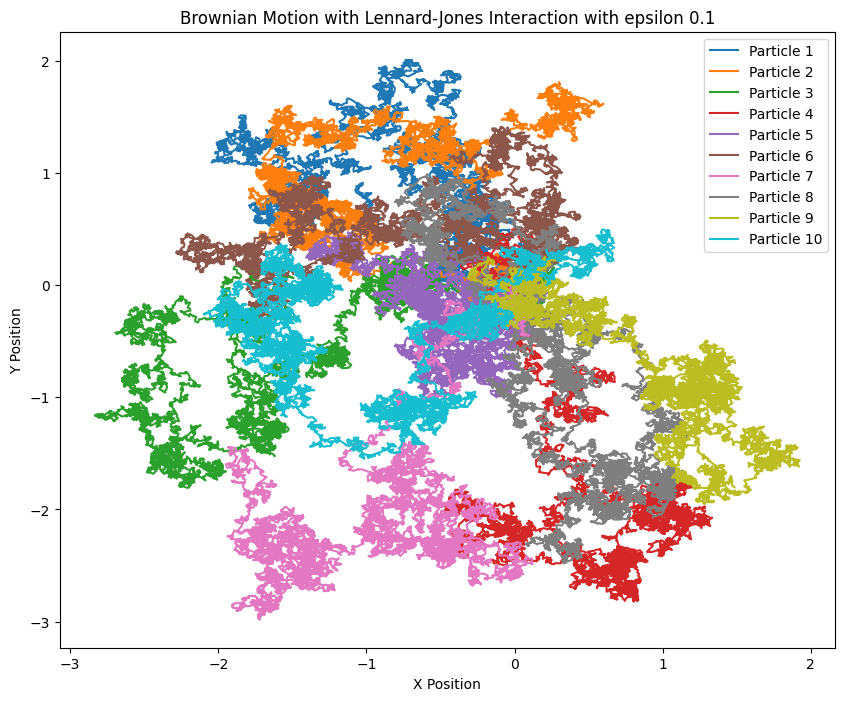

In [87]:
np.random.seed(48)
model = brownian_motion_with_LJ_interaction(10,10000,epsilon=0.1)
model.simulate(0.01)
model.plot()

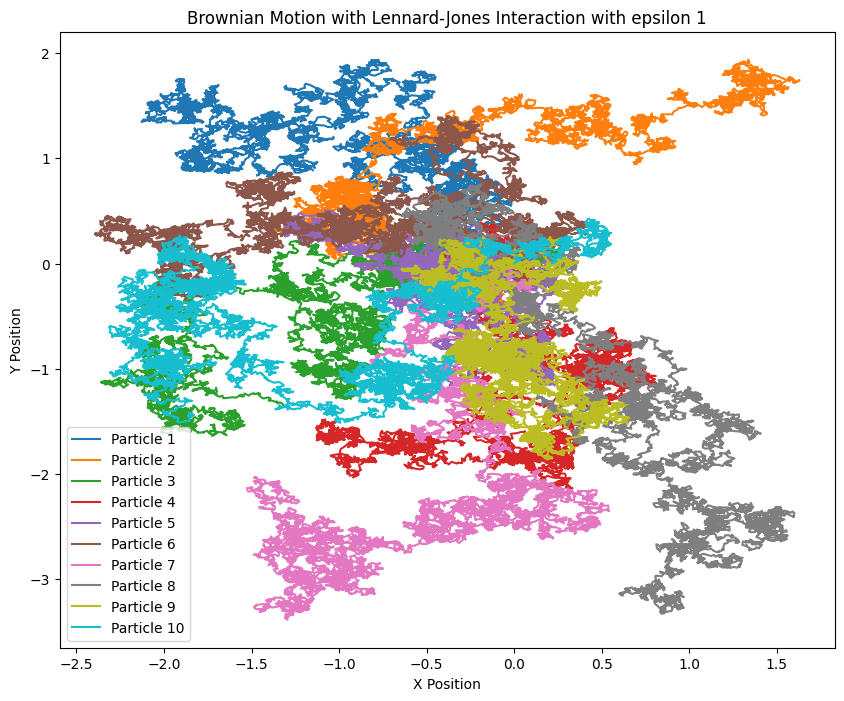

In [88]:
np.random.seed(48)
model = brownian_motion_with_LJ_interaction(10,10000,epsilon=1)
model.simulate(0.01)
model.plot()

Q2) Radius of Gyration

In [ ]:
def radius_of_gyration(x,y):
    r_cm_x = np.mean(x)
    r_cm_y = np.mean(y)
    rg = np.sqrt(np.mean((x-r_cm_x)**2 + (y-r_cm_y)**2))
    return rg



In [91]:
model = brownian_motion_without_interaction(10,1000)
x,y = model.simulate(0.01)
print(radius_of_gyration(x[-1],y[-1]))

0.6939055314661815


In [92]:
model = brownian_motion_with_LJ_interaction(10,1000,0.1,1)
x,y = model.simulate(0.01)
print(radius_of_gyration(x[-1],y[-1]))

0.5165300870345934


In [93]:
model = brownian_motion_with_LJ_interaction(10,1000,1,1)
x,y = model.simulate(0.01)
print(radius_of_gyration(x[-1],y[-1]))

0.744857622386555


Q3) MSD

In [ ]:
def MSD(x,y):
    msd = (np.mean(x**2 + y**2, axis = 0))
    plt.figure(figsize=(10,8))
    plt.plot(msd)
    plt.xlabel("Time")
    plt.ylabel("MSD")
    plt.title("MSD vs time")
    plt.show()

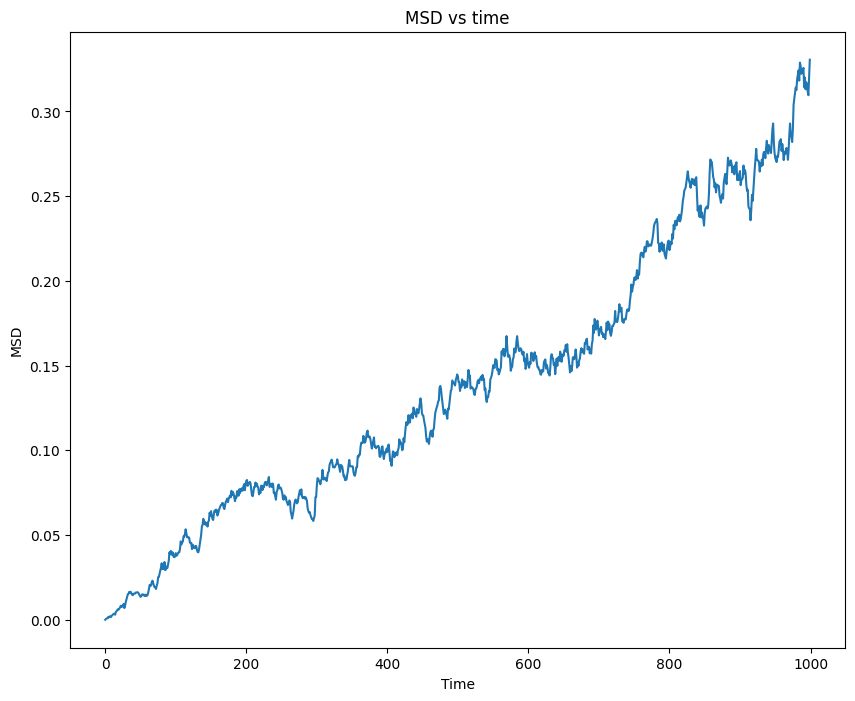

In [94]:
model = brownian_motion_without_interaction(10,1000)
x,y = model.simulate(0.01)
MSD(x.T,y.T)

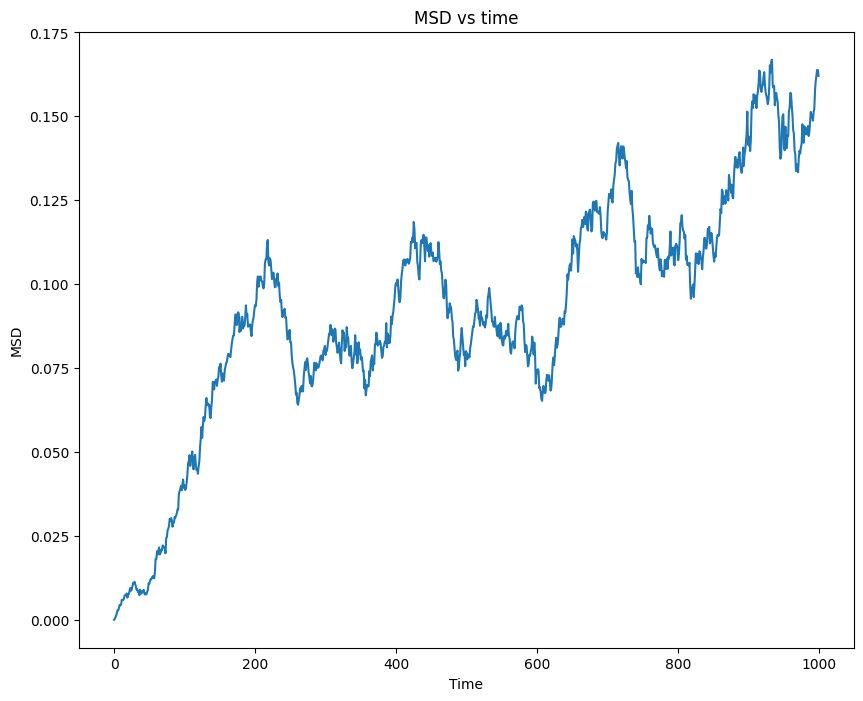

In [95]:
model = brownian_motion_with_LJ_interaction(10,1000,0.1,1)
x,y = model.simulate(0.01)
MSD(x.T,y.T)

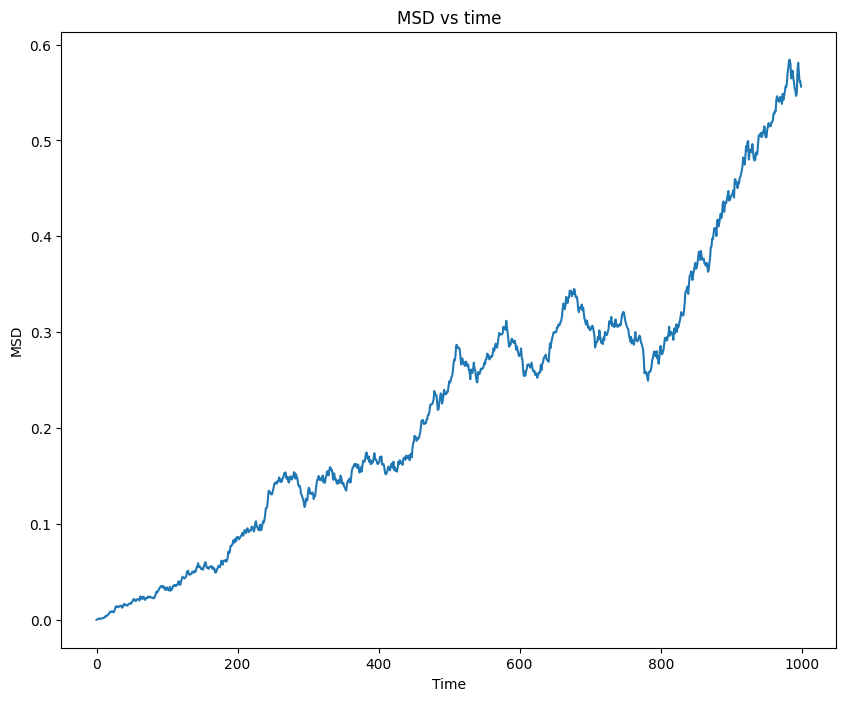

In [96]:
model = brownian_motion_with_LJ_interaction(10,1000,1,1)
x,y = model.simulate(0.01)
MSD(x.T,y.T)